In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

PASTA_DADOS = Path('dados_tratados')
META_ANUAL = 88000
META_COLABORATIVA = 70000

In [8]:
def carregar_dados_tratados(caminho=PASTA_DADOS / 'projetos_tratados.csv'):
    return pd.read_csv(caminho, parse_dates=['data_inicio', 'data_fim', 'data_registro'])

df = carregar_dados_tratados()
df.head()

,data_registro,nome_projeto,area,responsavel,cliente,satisfacao,valor_total_projeto,valor_faturamento_colaborativo,projeto_de_impacto,data_inicio,data_fim,status,ano_inicio,mes_inicio,ano_mes_inicio,duracao_dias,valor_faturamento_proprio
0,2026-09-07 15:31:26,Projeto Umbra,Mobile,Juliana Lima,Aurora Labs,5.0,2500,0,False,2024-03-09,2024-04-09,Concluído,2024,3,2024-03,31,2500
1,2026-09-06 15:31:26,Projeto Constelação,Sites,Marcos Vinícius,Delta Consult,5.0,5000,5000,False,2024-04-19,2024-05-19,Concluído,2024,4,2024-04,30,0
2,2026-09-05 15:31:26,Projeto Solstício,Mobile,Rafael Souza,NimbusSoft,4.0,3000,0,False,2024-05-11,2024-06-11,Concluído,2024,5,2024-05,31,3000
3,2026-09-04 15:31:26,Projeto Vetor,Desktop,Pedro de Pádua,Jagger CO,4.0,17000,0,False,2024-07-21,2024-08-21,Concluído,2024,7,2024-07,31,17000
4,2026-09-03 15:31:26,Projeto Odisseia,Desktop,Marcos Vinícius,Delta Consult,4.0,7000,0,False,2024-08-01,2024-09-01,Concluído,2024,8,2024-08,31,7000


In [9]:
def construir_serie_mensal(df, coluna_data='data_inicio'):
    df = df.copy()
    df['ano_mes'] = df[coluna_data].dt.to_period('M')
    serie = df.groupby('ano_mes').agg(
        faturamento_total=('valor_total_projeto', 'sum'),
        faturamento_colaborativo=('valor_faturamento_colaborativo', 'sum'),
        faturamento_proprio=('valor_faturamento_proprio', 'sum'),
    )

    idx_completo = pd.period_range(serie.index.min(), serie.index.max(), freq='M')
    n_preenchidos = len(idx_completo) - len(serie)
    if n_preenchidos > 0:
        print(f'[info] {n_preenchidos} mes(es) sem projetos iniciados foram preenchidos com faturamento = 0.')
    serie = serie.reindex(idx_completo, fill_value=0)
    serie.index.name = 'ano_mes'
    serie = serie.reset_index()
    serie['ano_mes'] = serie['ano_mes'].astype(str)
    serie['def'] = range(len(serie))
    serie['faturamento_total_acumulado'] = serie['faturamento_total'].cumsum()
    serie['faturamento_colaborativo_acumulado'] = serie['faturamento_colaborativo'].cumsum()
    return serie

serie = construir_serie_mensal(df)
serie

[info] 14 mes(es) sem projetos iniciados foram preenchidos com faturamento = 0.


,ano_mes,faturamento_total,faturamento_colaborativo,faturamento_proprio,indice_tempo,faturamento_total_acumulado,faturamento_colaborativo_acumulado
0,2024-03,2500,0,2500,0,2500,0
1,2024-04,5000,5000,0,1,7500,5000
2,2024-05,3000,0,3000,2,10500,5000
3,2024-06,0,0,0,3,10500,5000
4,2024-07,17000,0,17000,4,27500,5000
5,2024-08,27000,20000,7000,5,54500,25000
6,2024-09,10000,0,10000,6,64500,25000
7,2024-10,15000,0,15000,7,79500,25000
8,2024-11,35000,35000,0,8,114500,60000
9,2024-12,0,0,0,9,114500,60000


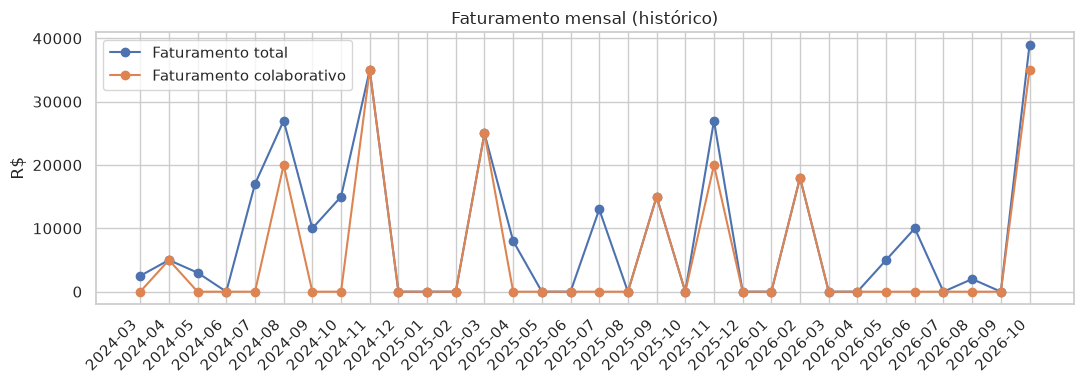

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(serie['ano_mes'], serie['faturamento_total'], marker='o', label='Faturamento total')
ax.plot(serie['ano_mes'], serie['faturamento_colaborativo'], marker='o', label='Faturamento colaborativo')
ax.set_xticks(range(len(serie)))
ax.set_xticklabels(serie['ano_mes'], rotation=45, ha='right')
ax.set_ylabel('R$')
ax.set_title('Faturamento mensal (histórico)')
ax.legend()
plt.tight_layout()
plt.show()


In [20]:
def escolher_modelo(serie, coluna_alvo, min_pontos_teste=3):
    n = len(serie)
    n_teste = min(min_pontos_teste, n // 4) if n >= 8 else 0
    if n_teste == 0:
        print(f'[{coluna_alvo}] dados insuficientes para holdout — usando regressão linear por padrão.')
        return 'linear'

    treino, teste = serie.iloc[:n - n_teste], serie.iloc[n - n_teste:]
    baseline_valor = treino[coluna_alvo].tail(3).mean()
    modelo = LinearRegression().fit(treino[['indice_tempo']].values, treino[coluna_alvo].values)

    mae_base = mean_absolute_error(teste[coluna_alvo], np.repeat(baseline_valor, n_teste))
    mae_linear = mean_absolute_error(teste[coluna_alvo], modelo.predict(teste[['indice_tempo']].values))
    print(f'[{coluna_alvo}] MAE baseline: R$ {mae_base:,.2f} | MAE regressão linear: R$ {mae_linear:,.2f}')

    return 'baseline' if mae_base < mae_linear else 'linear'

In [21]:
def prever_linear(serie, coluna_alvo, meses_futuros=6):
    X = serie[['indice_tempo']].values
    y = serie[coluna_alvo].values
    modelo = LinearRegression().fit(X, y)
    residuos = y - modelo.predict(X)
    desvio = residuos.std(ddof=1) if len(residuos) > 1 else 0.0

    ultimo_indice = serie['indice_tempo'].max()
    ultimo_mes = pd.Period(serie['ano_mes'].iloc[-1], freq='M')
    indices_futuros = np.arange(ultimo_indice + 1, ultimo_indice + 1 + meses_futuros)
    meses_labels = [str(ultimo_mes + i) for i in range(1, meses_futuros + 1)]

    previsto = np.clip(modelo.predict(indices_futuros.reshape(-1, 1)), 0, None)
    return pd.DataFrame({
        'ano_mes': meses_labels,
        f'{coluna_alvo}_previsto': previsto,
        f'{coluna_alvo}_intervalo_inferior': np.clip(previsto - 1.96 * desvio, 0, None),
        f'{coluna_alvo}_intervalo_superior': previsto + 1.96 * desvio,
    })

def prever_baseline(serie, coluna_alvo, meses_futuros=6, janela=3):
    valor_base = serie[coluna_alvo].tail(janela).mean()
    ultimo_mes = pd.Period(serie['ano_mes'].iloc[-1], freq='M')
    meses_labels = [str(ultimo_mes + i) for i in range(1, meses_futuros + 1)]
    desvio = serie[coluna_alvo].std(ddof=1) if len(serie) > 1 else 0.0
    previsto = np.repeat(valor_base, meses_futuros)
    return pd.DataFrame({
        'ano_mes': meses_labels,
        f'{coluna_alvo}_previsto': previsto,
        f'{coluna_alvo}_intervalo_inferior': np.clip(previsto - 1.96 * desvio, 0, None),
        f'{coluna_alvo}_intervalo_superior': previsto + 1.96 * desvio,
    })

def gerar_previsao(serie, coluna_alvo, meses_futuros=6):
    metodo = escolher_modelo(serie, coluna_alvo)
    previsao = prever_linear(serie, coluna_alvo, meses_futuros) if metodo == 'linear' else prever_baseline(serie, coluna_alvo, meses_futuros)
    print(f'[{coluna_alvo}] modelo escolhido: {metodo}')
    return previsao, metodo

previsao_total, metodo_total = gerar_previsao(serie, 'faturamento_total')
previsao_colaborativo, metodo_colaborativo = gerar_previsao(serie, 'faturamento_colaborativo')
previsao_total


[faturamento_total] MAE baseline: R$ 14,000.00 | MAE regressão linear: R$ 14,116.09
[faturamento_total] modelo escolhido: baseline
[faturamento_colaborativo] MAE baseline: R$ 11,666.67 | MAE regressão linear: R$ 12,878.16
[faturamento_colaborativo] modelo escolhido: baseline


,ano_mes,faturamento_total_previsto,faturamento_total_intervalo_inferior,faturamento_total_intervalo_superior
0,2026-11,13666.666667,0.0,35945.007217
1,2026-12,13666.666667,0.0,35945.007217
2,2027-01,13666.666667,0.0,35945.007217
3,2027-02,13666.666667,0.0,35945.007217
4,2027-03,13666.666667,0.0,35945.007217
5,2027-04,13666.666667,0.0,35945.007217


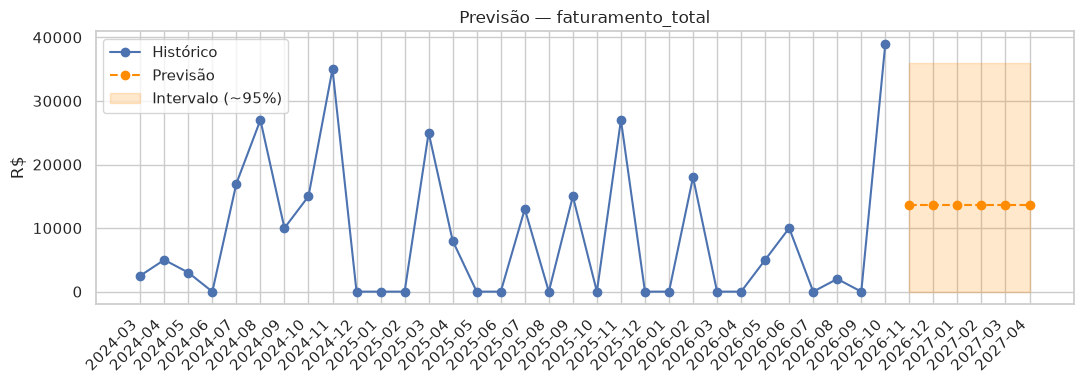

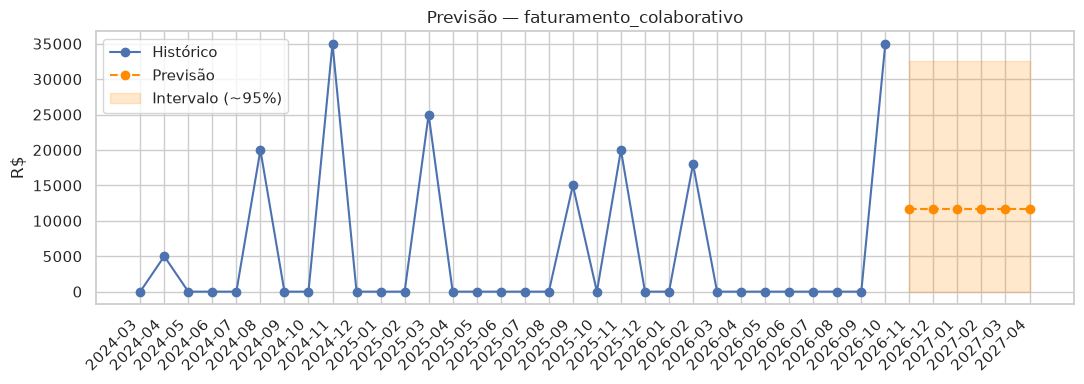

In [22]:
def plotar_previsao(serie, previsao, coluna_alvo, meta=None):
    coluna_previsto = f'{coluna_alvo}_previsto'
    coluna_inf = f'{coluna_alvo}_intervalo_inferior'
    coluna_sup = f'{coluna_alvo}_intervalo_superior'

    eixo_hist = list(range(len(serie)))
    eixo_prev = list(range(len(serie), len(serie) + len(previsao)))

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(eixo_hist, serie[coluna_alvo], marker='o', label='Histórico')
    ax.plot(eixo_prev, previsao[coluna_previsto], marker='o', linestyle='--', color='darkorange', label='Previsão')
    ax.fill_between(eixo_prev, previsao[coluna_inf], previsao[coluna_sup], color='darkorange', alpha=0.2, label='Intervalo (~95%)')

    if meta is not None:
        ax.axhline(meta, color='red', linestyle=':', label=f'Meta (R$ {meta:,.0f})')

    rotulos = list(serie['ano_mes']) + list(previsao['ano_mes'])
    ax.set_xticks(range(len(rotulos)))
    ax.set_xticklabels(rotulos, rotation=45, ha='right')
    ax.set_ylabel('R$')
    ax.set_title(f'Previsão — {coluna_alvo}')
    ax.legend()
    plt.tight_layout()
    plt.show()

plotar_previsao(serie, previsao_total, 'faturamento_total')
plotar_previsao(serie, previsao_colaborativo, 'faturamento_colaborativo')

In [23]:
def calcular_trajetoria_meta(serie, previsao, coluna_alvo, meta, ano_referencia=None):
    hist = serie.copy()
    hist['ano'] = hist['ano_mes'].str[:4].astype(int)
    if ano_referencia is None:
        ano_referencia = hist['ano'].max()
    realizado = hist.loc[hist['ano'] == ano_referencia, coluna_alvo].sum()

    prev = previsao.copy()
    prev['ano'] = prev['ano_mes'].str[:4].astype(int)
    projetado_futuro = prev.loc[prev['ano'] == ano_referencia, f'{coluna_alvo}_previsto'].sum()

    total_projetado = realizado + projetado_futuro
    return {
        'ano_referencia': int(ano_referencia),
        'realizado_ate_agora': float(realizado),
        'projetado_meses_restantes': float(projetado_futuro),
        'total_projetado_ano': float(total_projetado),
        'meta': meta,
        'gap_para_meta': float(meta - total_projetado),
        'atingira_meta': bool(total_projetado >= meta),
    }

def imprimir_trajetoria(traj, nome_metrica):
    status = '✅ dentro da meta' if traj['atingira_meta'] else '⚠️ abaixo da meta'
    print(f"{nome_metrica} — ano {traj['ano_referencia']}")
    print(f"  Realizado até agora:            R$ {traj['realizado_ate_agora']:,.2f}")
    print(f"  Projetado (meses restantes):    R$ {traj['projetado_meses_restantes']:,.2f}")
    print(f"  Total projetado no ano:         R$ {traj['total_projetado_ano']:,.2f}")
    print(f"  Meta:                           R$ {traj['meta']:,.2f}")
    print(f"  Gap:                            R$ {traj['gap_para_meta']:,.2f}  ({status})")
    print()

trajetoria_total = calcular_trajetoria_meta(serie, previsao_total, 'faturamento_total', META_ANUAL)
trajetoria_colaborativo = calcular_trajetoria_meta(serie, previsao_colaborativo, 'faturamento_colaborativo', META_COLABORATIVA)

imprimir_trajetoria(trajetoria_total, 'Faturamento total')
imprimir_trajetoria(trajetoria_colaborativo, 'Faturamento colaborativo')


Faturamento total — ano 2026
  Realizado até agora:            R$ 74,000.00
  Projetado (meses restantes):    R$ 27,333.33
  Total projetado no ano:         R$ 101,333.33
  Meta:                           R$ 88,000.00
  Gap:                            R$ -13,333.33  (✅ dentro da meta)

Faturamento colaborativo — ano 2026
  Realizado até agora:            R$ 53,000.00
  Projetado (meses restantes):    R$ 23,333.33
  Total projetado no ano:         R$ 76,333.33
  Meta:                           R$ 70,000.00
  Gap:                            R$ -6,333.33  (✅ dentro da meta)

